# Overview

You will be forecasting the outcomes of both the men's and women's 2025 collegiate basketball tournaments, by submitting predictions for every possible tournament matchup.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb
import plotly.express as px
from pathlib import Path

In [2]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/march-machine-learning-mania-2025/Conferences.csv
/kaggle/input/march-machine-learning-mania-2025/SeedBenchmarkStage1.csv
/kaggle/input/march-machine-learning-mania-2025/WNCAATourneyDetailedResults.csv
/kaggle/input/march-machine-learning-mania-2025/WRegularSeasonCompactResults.csv
/kaggle/input/march-machine-learning-mania-2025/MNCAATourneySeedRoundSlots.csv
/kaggle/input/march-machine-learning-mania-2025/MRegularSeasonDetailedResults.csv
/kaggle/input/march-machine-learning-mania-2025/MNCAATourneyCompactResults.csv
/kaggle/input/march-machine-learning-mania-2025/MGameCities.csv
/kaggle/input/march-machine-learning-mania-2025/WSecondaryTourneyCompactResults.csv
/kaggle/input/march-machine-learning-mania-2025/WGameCities.csv
/kaggle/input/march-machine-learning-mania-2025/MSeasons.csv
/kaggle/input/march-machine-learning-mania-2025/WNCAATourneySlots.csv
/kaggle/input/march-machine-learning-mania-2025/MSecondaryTourneyTeams.csv
/kaggle/input/march-machine-learning-mania-20

In [3]:
#i am already inside the folder

all_files = glob.glob('/kaggle/input/**/*.csv', recursive=True) 

In [4]:
files_dict = {Path(file).stem : pd.read_csv(file, encoding='latin-1') for file in all_files}

# 1. Understanding my Datasets

## Data Section 1 - The Basics

This section provides everything you need to build a simple prediction model and submit predictions.

#### 1.1 MTeams.csv and WTeams.csv
-  The men's team ID's range from 1000-1999, whereas all of the women's team ID's range from 3000-3999.

- the `LastD1Season` and `FirstD1Season` only exist in the men's data.

In [5]:
teams = pd.concat([files_dict['MTeams'],files_dict['WTeams']],axis=0)
teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014.0,2025.0
1,1102,Air Force,1985.0,2025.0
2,1103,Akron,1985.0,2025.0
3,1104,Alabama,1985.0,2025.0
4,1105,Alabama A&M,2000.0,2025.0


#### 1.2 MSeasons.csv and WSeasons.csv

- **DayZero** - tells you the date corresponding to DayNum=0 during that season. All game dates have been aligned upon a common scale so that (each year) the Monday championship game of the men's tournament is on DayNum=154. Working backward, the men's national semifinals are always on DayNum=152, the men's "play-in" games are on days 134-135, Selection Sunday is on day 132, the final day of the regular season is also day 132, and so on. All game data includes the day number in order to make it easier to perform date calculations. If you need to know the exact date a game was played on, you can combine the game's "DayNum" with the season's "DayZero". 

For instance, since day zero during the 2011-2012 season was 10/31/2011, if we know that the earliest regular season games that year were played on DayNum=7, they were therefore played on 11/07/2011. Also note that the men's and women's data share the same DayZero each season, although the women's championship game is not necessarily played on DayNum=154

In [6]:
seasons = pd.concat([files_dict['MSeasons'], files_dict['WSeasons']], axis = 0)
seasons.head()

,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1985,10/29/1984,East,West,Midwest,Southeast
1,1986,10/28/1985,East,Midwest,Southeast,West
2,1987,10/27/1986,East,Southeast,Midwest,West
3,1988,11/02/1987,East,Midwest,Southeast,West
4,1989,10/31/1988,East,West,Midwest,Southeast


#### 1.3 MNCAATourneySeeds.csv and WNCAATourneySeeds.csv

_check data glossary to understand the dataset_

In [7]:
seeds = pd.concat([files_dict['MNCAATourneySeeds'], files_dict['WNCAATourneySeeds']], axis = 0)
seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


#### 1.4 MRegularSeasonCompactResults.csv and WRegularSeasonCompactResults.csv

In [8]:
rsc_results =  pd.concat([files_dict['MRegularSeasonCompactResults'], 
            files_dict['WRegularSeasonCompactResults']], 
           axis = 0)

#### How to interpret NumOT

NumOT	|Meaning|	Total Extra Time
---|---|----
0	|Game ended in regulation|	0 minutes
1	|One overtime	|5 minutes
2|	Double overtime	|10 minutes
3	|Triple overtime	|15 minutes
4	|Quadruple overtime|	20 minutes
5	|Five overtimes (very rare)	|25 minutes

#### 1.5 MNCAATourneyCompactResults.csv and WNCAATourneyCompactResults.csv

In [9]:
#tourney compact results
tc_results = pd.concat([files_dict['MNCAATourneyCompactResults'], 
                          files_dict['WNCAATourneyCompactResults']], axis = 0)

tc_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


## Data Section 2 - 

In a Detailed Results file, the first eight columns (**Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, and NumOT**) are exactly the same as a Compact Results file. However, in a Detailed Results file, there are many additional columns. The column names should be self-explanatory to basketball fans (as above, "W" or "L" refers to the winning or losing team):

- `WFGM` - field goals made (by the winning team)

- `WFGA` - field goals attempted (by the winning team)

- `WFGM3` - three pointers made (by the winning team)

- `WFGA3` - three pointers attempted (by the winning team)

- `WFTM` - free throws made (by the winning team)

- `WFTA` - free throws attempted (by the winning team)

- `WOR` - offensive rebounds (pulled by the winning team)

- `WDR` - defensive rebounds (pulled by the winning team)

- `WAst` - assists (by the winning team)

- `WTO` - turnovers committed (by the winning team)

- `WStl` - steals (accomplished by the winning team)

- `WBlk` - blocks (accomplished by the winning team)

- `WPF` - personal fouls committed (by the winning team)

#### 2.1 MRegularSeasonDetailedResults.csv and WRegularSeasonDetailedResults.csv

In [10]:
#regular season detailed results
rsd_results = pd.concat([files_dict['MRegularSeasonDetailedResults'],
          files_dict['WRegularSeasonDetailedResults']],axis=0)

rsd_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


#### 2.2 MNCAATourneyDetailedResults.csv and WNCAATourneyDetailedResults.csv

In [11]:
#tourney detailed results
td_results = pd.concat([files_dict['MNCAATourneyDetailedResults'], 
           files_dict['WNCAATourneyDetailedResults']], 
          axis = 0)

td_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,...,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,...,21,15,20,10,26,16,14,5,8,19


## Data Section 3 - Geography

This section provides city locations of all regular season, conference tournament, and NCAA® tournament games since the 2010 season

In [12]:
cities = files_dict['Cities']

cities.head()

,CityID,City,State
0,4001,Abilene,TX
1,4002,Akron,OH
2,4003,Albany,NY
3,4004,Albuquerque,NM
4,4005,Allentown,PA


In [13]:
game_cities = pd.concat([files_dict['MGameCities'], files_dict['WGameCities']], axis = 0)

game_cities.head()

,Season,DayNum,WTeamID,LTeamID,CRType,CityID
0,2010,7,1143,1293,Regular,4027
1,2010,7,1314,1198,Regular,4061
2,2010,7,1326,1108,Regular,4080
3,2010,7,1393,1107,Regular,4340
4,2010,9,1143,1178,Regular,4027


## Data Section 4 - Public Rankings
This section provides weekly team rankings (men's teams only) for dozens of top rating systems - Pomeroy, Sagarin, RPI, ESPN, etc., since the 2003 season

In [14]:
files_dict['MMasseyOrdinals'].head()

,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260


## Data Section 5 - Supplements

This section contains additional supporting information, including coaches, conference affiliations, alternative team name spellings, bracket structure, and game results for NIT and other postseason tournaments.

In [15]:
coaches = files_dict['MTeamCoaches']

coaches.head()

,Season,TeamID,FirstDayNum,LastDayNum,CoachName
0,1985,1102,0,154,reggie_minton
1,1985,1103,0,154,bob_huggins
2,1985,1104,0,154,wimp_sanderson
3,1985,1106,0,154,james_oliver
4,1985,1108,0,154,davey_whitney


In [16]:
tourney_result = td_results.copy()

I will create some new columns that will help me in this analysis:

1. FG%

2. 3P%

3. FT%

4. Assist to turnover ratio

5. TS%

In [17]:
tourney_result['WFG%'] = (tourney_result['WFGM'] / tourney_result['WFGA']) * 100          #FG% for winning team
tourney_result['LFG%'] = (tourney_result['LFGM'] / tourney_result['LFGA']) * 100          #FG% of losing team
tourney_result['WFG3%'] = (tourney_result['WFGM3'] / tourney_result['WFGA3']) * 100       #3point% of winning team
tourney_result['LFG3%'] = (tourney_result['LFGM3'] / tourney_result['LFGA3']) * 100       #3point% of losing team
tourney_result['WFT%'] = (tourney_result['WFTM'] / tourney_result['WFTA']) * 100          #FT% of winning team
tourney_result['LFT%'] = (tourney_result['LFTM'] / tourney_result['LFTA']) * 100          #FT% of losing team
tourney_result['WAst_TO_ratio'] = tourney_result['WAst'] / tourney_result['WTO']          #assist to turnover ratio
tourney_result['LAst_TO_ratio'] = tourney_result['LAst'] / tourney_result['LTO']

#TS% = (Points / (FGA + 0.44 * FTA))
tourney_result['WTS%'] = tourney_result['WScore'] / 2 * (tourney_result['WFGA'] + 0.44 * tourney_result['WFTA'])
tourney_result['LTS%'] = tourney_result['LScore'] / 2 * (tourney_result['LFGA'] + 0.44 * tourney_result['LFTA'])

### Why That `2 ×` Exists (One-Sentence Reminder)

Because the denominator represents shooting possessions, and TS% measures points per shooting possession relative to 2 points.

Without the `2 ×`, you’re measuring something else — not TS%.

Let's get into some analysis...

# 1. DATA ANALYSIS

**1. . What is the average score of winning teams vs losing teams by season?**

In [18]:
# Function to add centered value labels
def add_labels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha='center') 

In [19]:
px.bar( tourney_result.groupby('Season')[['WScore', 'LScore']].mean(), barmode='group')

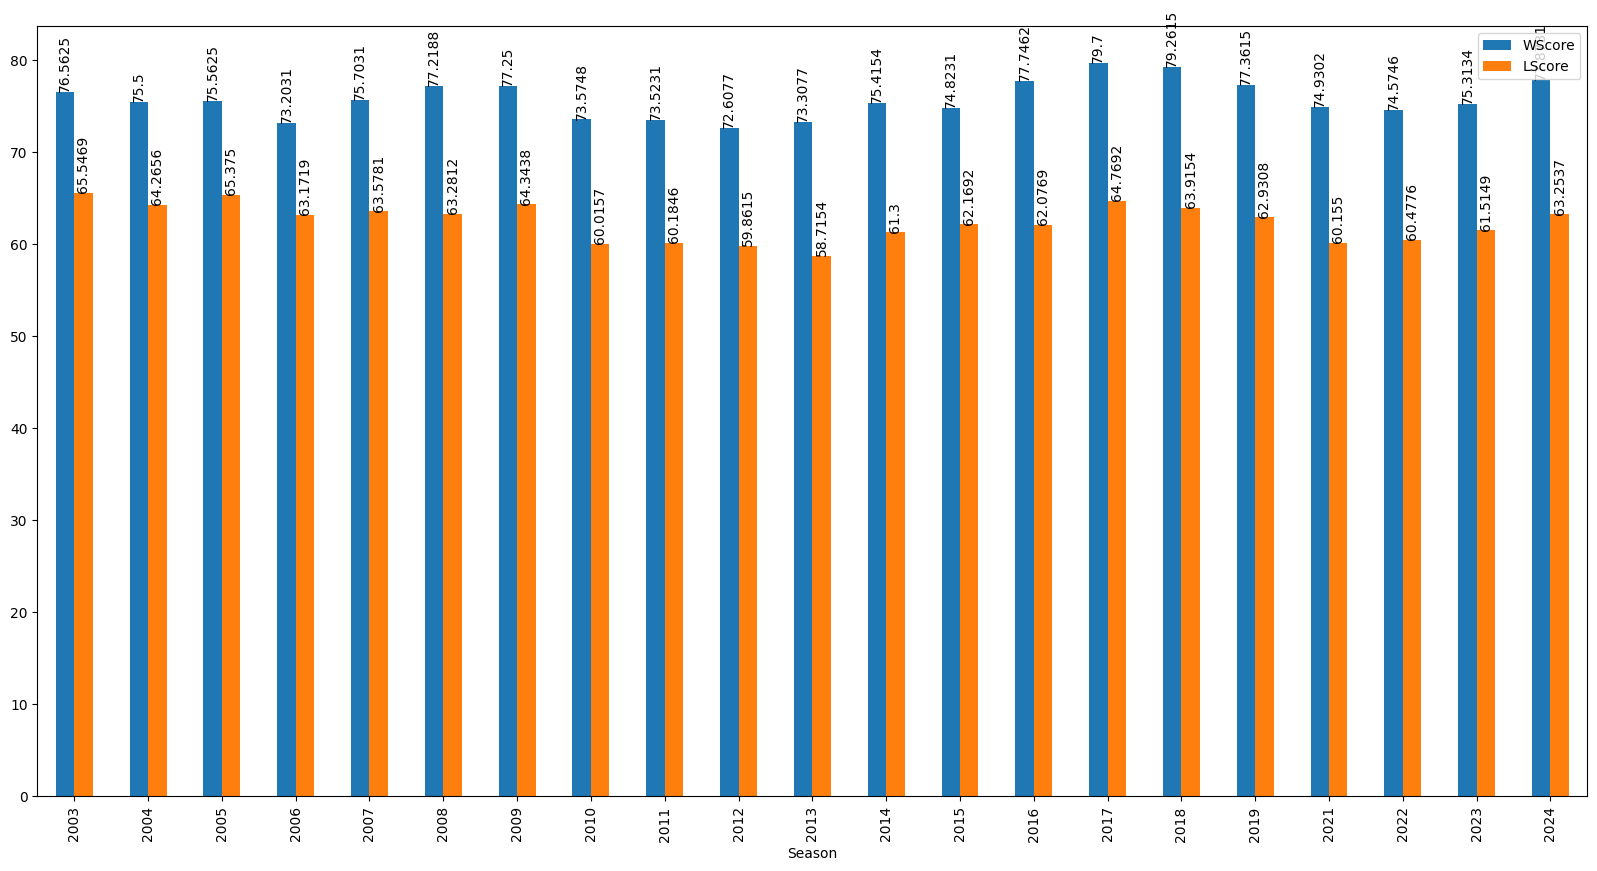

In [20]:
ax = tourney_result.groupby('Season')[['WScore', 'LScore']].mean().plot.bar(figsize = (20,10))

#add labels
for container in ax.containers:
    ax.bar_label(container, rotation = 90) #rotation rotates position of label

The average score of winning teams generally falls between 70 and 79 points, while losing teams average between 58 and 65 points.
This shows a fairly consistent scoring gap of roughly 10–15 points between winners and losers across seasons.

The averages remain relatively stable over time, suggesting that scoring levels in tournament games have not drastically changed across seasons.

**2. How often do games go to overtime (NumOT > 0)?**

In [21]:
OT_games = tourney_result[tourney_result['NumOT'] > 0]
count_OT = OT_games.groupby('Season')['NumOT'].count()
px.line(count_OT)

Overtime games are relatively rare in the tournament.
Across seasons, the number of games that go to overtime remains low, usually only a few games per season. This suggests that most games are decided within regulation time.

### Better Analytical approach to this question...

In [22]:
total_games = tourney_result.groupby('Season').size()

OT_games = tourney_result[tourney_result['NumOT'] > 0] \
            .groupby('Season').size()

OT_rate = (OT_games / total_games) * 100

px.line(
    OT_rate,
    labels={'value':'OT Percentage', 'Season':'Season'}
)

Now you are answering:

> What percentage of games go to overtime each season

Which is a much stronger analytical answer.

**5. How has scoring changed over time (Season vs average total points)?**

In [23]:
tourney_result['total_score'] = tourney_result['WScore'] + tourney_result['LScore']

px.line(tourney_result.groupby('Season')['total_score'].mean())

Average total points per game fluctuate across seasons rather than following a consistent upward or downward trend. Some periods, such as the mid-2000s, show a decline in scoring, while other periods show increases. This suggests that scoring levels in tournament games vary over time but remain within a relatively stable range overall.

**6. Do winning teams have higher field goal percentage (FG%) than losing teams?**

In [24]:
tourney_result[['WFG%', 'LFG%']].mean()

WFG%    47.111738
LFG%    38.434690
dtype: float64

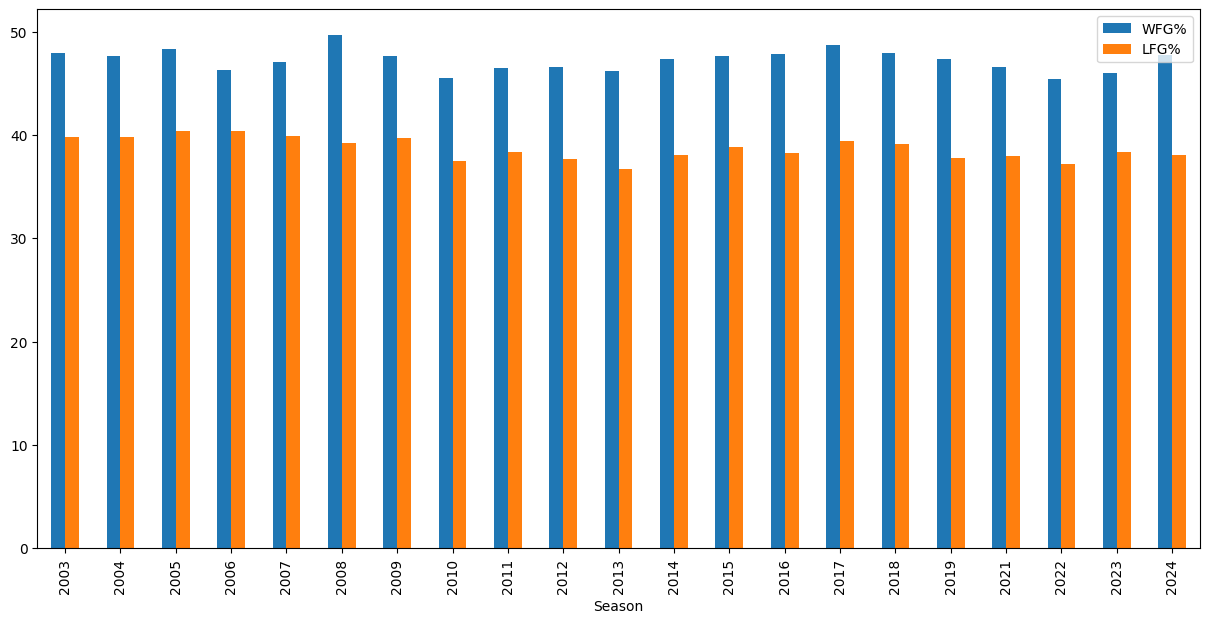

In [25]:
tourney_result.groupby('Season')[['WFG%', 'LFG%']].mean().plot.bar(figsize=(15,7));

Winning teams consistently have a higher field goal percentage than losing teams across all seasons. This suggests that shooting efficiency plays a significant role in determining game outcomes, as teams that convert a higher proportion of their shots are more likely to win.

**7. How much does 3-point shooting contribute to wins?**

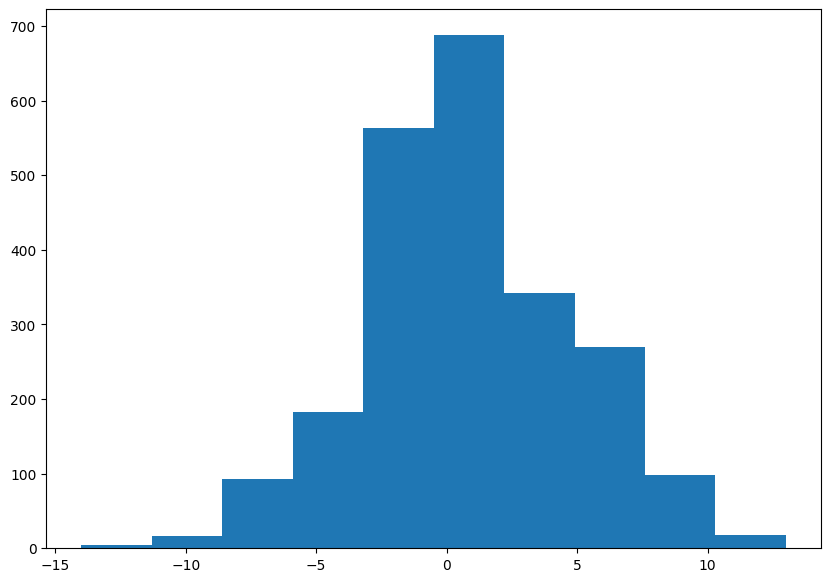

In [26]:
tourney_result['diff_3p'] = tourney_result['WFGM3'] - tourney_result['LFGM3']

plt.figure(figsize=(10,7))
plt.hist(tourney_result['diff_3p'])

plt.show()

### Interpreting the Histogram

The histogram shows how frequently each difference occurs.

Your x-axis:

- diff_3p

Your y-axis:

- number of games

#### What we observe

**1️⃣ The peak is around 0 to 2**

This means:

> Most games have a difference of about 0 to 2 three-pointers.

Interpretation:

> Winning teams typically make only slightly more three-pointers than losing teams.

**2️⃣ The distribution is centered near zero**

Meaning:

> The difference in three-point shooting is usually small.

This indicates:

> Three-point shooting alone does not dominate most games.

**3️⃣ The spread is wide**

Values go roughly from:

- -14  to  +12

Meaning:

> Some games have huge differences in 3-point shooting.

But they are **rare.**

#### Histogram Conclusion

A strong interpretation would be:

> The distribution of three-point differences is centered close to zero, meaning that most games have only small differences in three-point shooting between teams. While winning teams tend to make slightly more three-pointers, large differences occur only in a small number of games.

**3️⃣ Key Insight Combining Both Plots**

Both plots together suggest:

1️⃣ Winners slightly outperform losers in 3-point shooting

2️⃣ Most differences are small (0–2 shots)

3️⃣ Large shooting advantages exist but are rare

A Very Strong Final Answer You Could Write

Something like:

> The distribution of three-point differences is centered close to zero, indicating that most games have only small differences in made three-pointers between teams. The boxplot shows a slightly positive median, suggesting that winning teams generally make slightly more three-pointers than losing teams. However, the relatively small differences in most games suggest that while three-point shooting contributes to wins, it is not usually the sole determining factor.

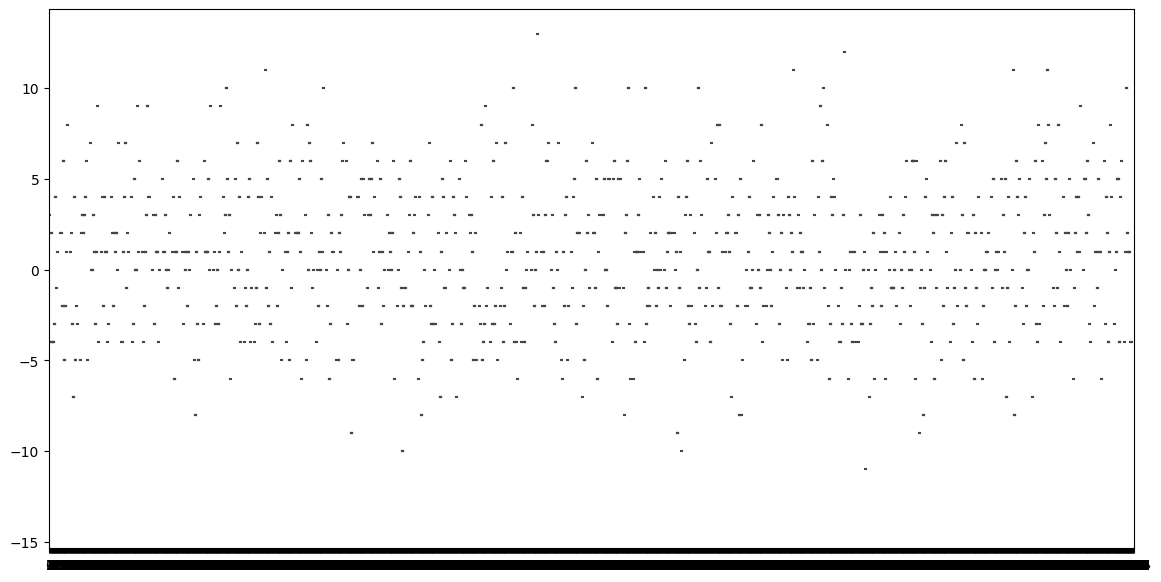

In [27]:
plt.figure(figsize=(14,7))
sb.boxplot(tourney_result['diff_3p'])

plt.show()

### Interpreting the Boxplot

Your boxplot represents diff_3p = WFGM3 − LFGM3

Meaning:

- Positive values → winners made more 3-pointers

- Negative values → losers made more 3-pointers

#### What each part shows

**Median (line inside the box)**

This is the middle value.

From your plot:

➡ The median is slightly above 0

**Interpretation**

> In a typical game, the winning team makes slightly more 3-pointers than the losing team.

**The Box (IQR)**

The box shows where 50% of games fall.

From your plot:

Roughly:

- -2  to  +3

**Interpretation**

> In half of the games, the difference in made 3-pointers between winners and losers is between about −2 and +3.

This tells us:

- Many games are fairly close in 3-point production.

**Whiskers**

These show the typical range excluding outliers.

Roughly:

- -9  to  +10

**Interpretation**

> In most games, the difference in made 3-pointers falls within about −9 to +10.

**Outliers**

Those dots at the ends are extreme games.

Example interpretation:

> In rare cases, a team may make 10+ more three-pointers than the opponent.

That’s a **huge shooting advantage.**

#### Boxplot Conclusion

A strong interpretation would be:

> The median difference in three-point shots is slightly positive, indicating that winning teams generally make more three-pointers than losing teams. However, the interquartile range shows that many games have relatively small differences in three-point shooting. Extreme cases exist where teams win with a very large three-point advantage.dd

**9. What percentage of total points comes from:**

- 2-pointers

- 3-pointers

- Free throws

In [28]:
#Step 1: Calculate total points by source

Wpct_2 = ((tourney_result['WFGM'] - tourney_result['WFGM3']) * 2).sum()
Wpct_3 = (tourney_result['WFGM3'] * 3).sum()
Wpct_ft = tourney_result['WFTM'].sum()
Lpct_2 = ((tourney_result['LFGM'] - tourney_result['LFGM3']) * 2).sum()
Lpct_3 = (tourney_result['LFGM3'] * 3).sum()
Lpct_ft = tourney_result['LFTM'].sum()
total_points = tourney_result['WScore'].sum()

#Step 2: Convert to percentages

Wpct_2 = (Wpct_2 / total_points) * 100
Wpct_3 = (Wpct_3 / total_points) * 100
Wpct_ft = (Wpct_ft / total_points) * 100
Lpct_2 = (Lpct_2 / total_points) * 100
Lpct_3 = (Lpct_3 / total_points) * 100
Lpct_ft = (Lpct_ft / total_points) * 100

#present answer cleanly

points_df = pd.DataFrame({
                        'Scoring Type': ['W2-pointers', 'W3-pointers', 'WFree throws', 
                                         'L2-pointers', 'L3-pointers', 'LFree throws'],
                        'Percentage of Total Points': [Wpct_2, Wpct_3, Wpct_ft, Lpct_2, Lpct_3, Lpct_ft]
                        }).round(2)

In [29]:
#lets see colors on plotly

#px.colors.sequential.swatches_continuous()

In [30]:
px.pie(points_df,
       values = 'Percentage of Total Points',
       names = 'Scoring Type',
       color_discrete_sequence=px.colors.sequential.Hot
       )

**10. Do teams that attempt more free throws win more often?**

In [31]:
tourney_result['more_FTA_often'] = (tourney_result['WFTA'] > tourney_result['LFTA']).astype(int)

tourney_result['more_FTA_often'].mean()

0.7152899824253075

Teams with more FTA win 72% of the time.

**13. Is total rebounding (OR + DR) a strong predictor of winning?**

In [32]:
rebounds = tourney_result[['Season','WScore','LScore','WDR','WOR','LDR','LOR']].copy()
rebounds['W_rebounds'] = rebounds['WOR'] + rebounds['WDR']
rebounds['L_rebounds'] = rebounds['LOR'] + rebounds['LDR']

(rebounds['W_rebounds'] > rebounds['L_rebounds']).mean()

0.680140597539543

Teams with more rebounds win 68% of the time...it is a good predictor of winning, but not a strong one

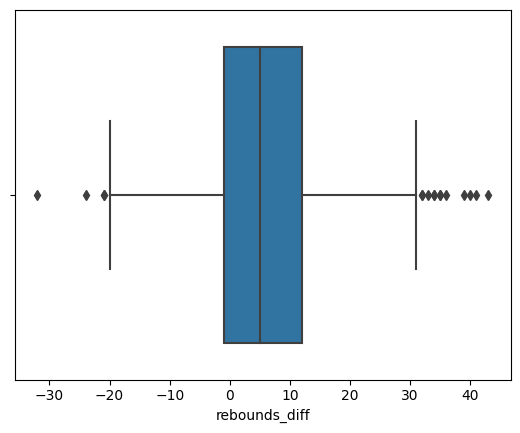

In [33]:
rebounds['rebounds_diff'] = rebounds['W_rebounds'] - rebounds['L_rebounds']

sb.boxplot(data = rebounds, x = 'rebounds_diff')
plt.show()

Total rebounds have a moderate relationship with winning. Teams with more rebounds win about 68% of the time, suggesting rebounding contributes to success but is not a dominant predictor of victory.

The boxplot shows that winning teams consistently record more total rebounds than losing teams. While there is some overlap between the distributions, the higher median and upward shift suggest that rebounding is an important contributing factor to winning, though not a sole determinant.

**14. What matters more: offensive rebounds or defensive rebounds?**

In [34]:
rebounds['W_have_more_OR'] = (rebounds['WOR'] > rebounds['LOR'])
rebounds['W_have_more_DR'] = (rebounds['WDR'] > rebounds['LDR'])

In [35]:
rebounds[['W_have_more_OR','W_have_more_DR']].mean()

W_have_more_OR    0.464411
W_have_more_DR    0.758787
dtype: float64

Winning teams have more defensive rebounds about 76% of the time, while they have more offensive rebounds only 46% of the time, suggesting defensive rebounding has a stronger association with winning.

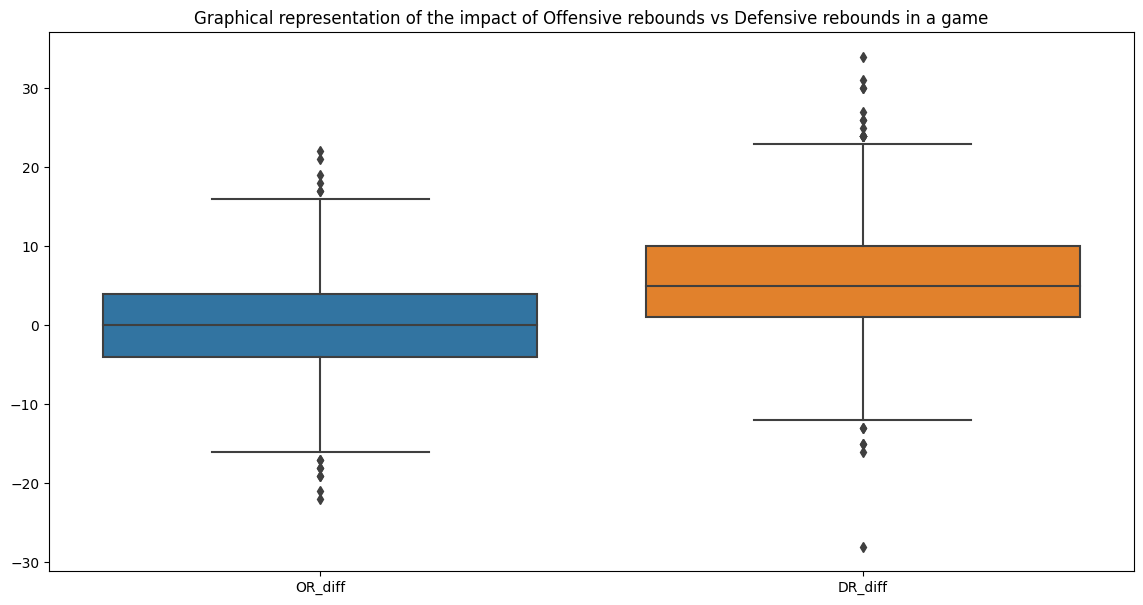

In [36]:
rebounds['OR_diff'] = rebounds['WOR'] - rebounds['LOR']
rebounds['DR_diff'] = rebounds['WDR'] - rebounds['LDR']

#--BOX PLOT--

plt.figure(figsize=(14,7))
sb.boxplot(data = rebounds[['OR_diff', 'DR_diff']])
plt.title('Graphical representation of the impact of Offensive rebounds vs Defensive rebounds in a game')
plt.show()

In [37]:
sb.palettes.SEABORN_PALETTES.keys()

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])

**16. Do winning teams record more assists than losing teams?**

In [38]:
(tourney_result['WAst'] > tourney_result['LAst']).mean()

0.6902460456942003

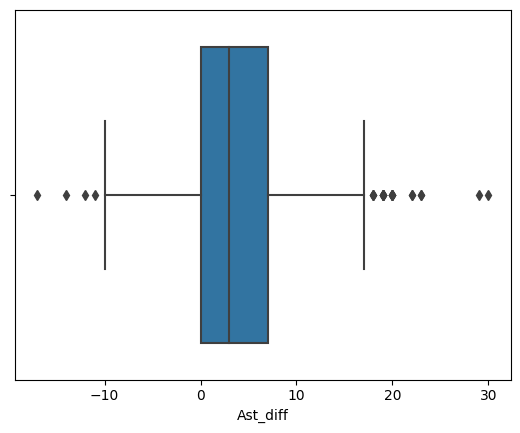

In [39]:
tourney_result['Ast_diff'] = tourney_result['WAst'] - tourney_result['LAst']

sb.boxplot(data = tourney_result, x = 'Ast_diff')
plt.show()

Winning Team record more assist than the losing team 69% of the time

**Is assist-to-turnover ratio a better predictor than raw assists?**

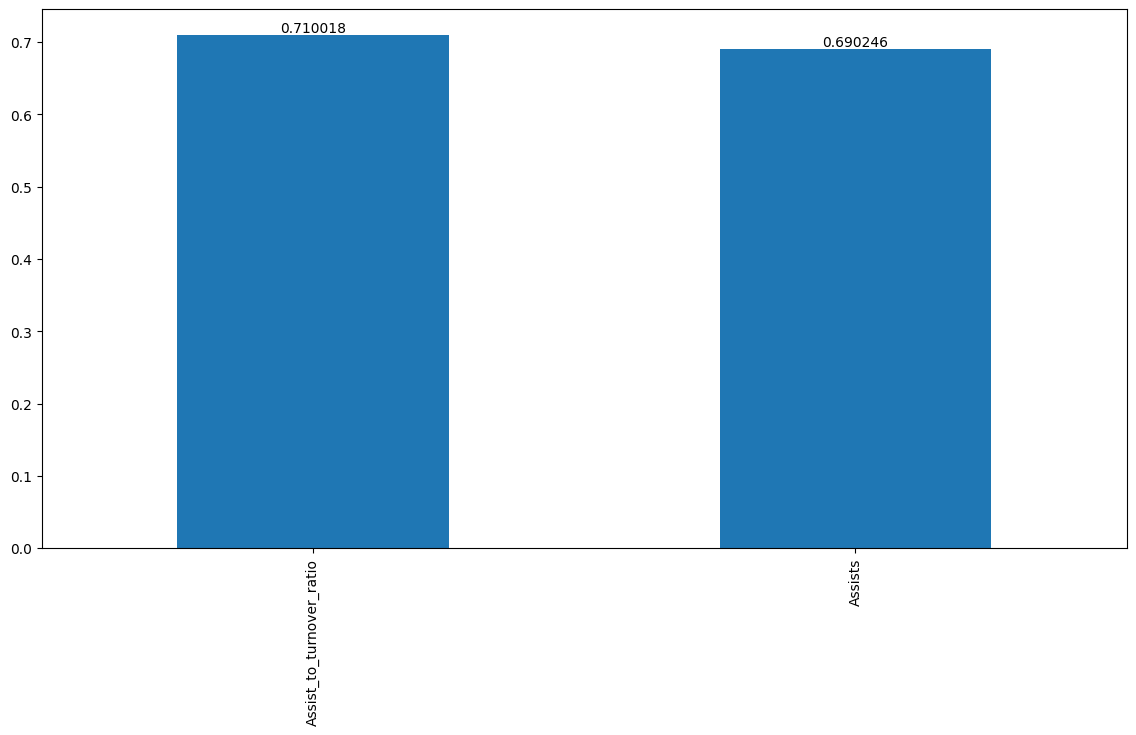

In [40]:
ax = pd.Series({
'Assist_to_turnover_ratio' : (tourney_result['WAst_TO_ratio'] > tourney_result['LAst_TO_ratio']).mean(),
'Assists' : (tourney_result['WAst'] > tourney_result['LAst']).mean()
}).plot.bar(figsize=(14,7))

#add labels
for container in ax.containers:
    ax.bar_label(container) #rotation rotates position of label

plt.show()

Assist to turnover ratio is a slightly better predictor than raw assist

**19. Do high-turnover teams rely more on free throws or offensive rebounds to win?**

_**Helpful formulas:**_
- Possession = (FGA-OR) + TO + (.475 X FTA)

- Turnover percentage per possession: TO/(FGA-OR) + TO + (.475 X FTA)

- Turnover Rate per 100 possessions: TO X 100/(FGA-OR) + TO + (.475 X FTA)

In [41]:
tourney_result['W_possesions'] = (tourney_result['WFGA'] - tourney_result['WOR']) + tourney_result['WTO'] + (tourney_result['WFTA'] * .475)
tourney_result['L_possesions'] = (tourney_result['LFGA'] - tourney_result['LOR']) + tourney_result['LTO'] + (tourney_result['LFTA'] * .475)

tourney_result['W_TO_rate'] = 100 * (tourney_result['WTO'] / tourney_result['W_possesions'])
tourney_result['L_TO_rate'] = 100 * (tourney_result['LTO'] / tourney_result['L_possesions'])

In [42]:
#turnover rate of over 18% is considered to be generally high

#create a df of games were winning team had high TO rate

high_TO_games = tourney_result[tourney_result['W_TO_rate'] > 18]

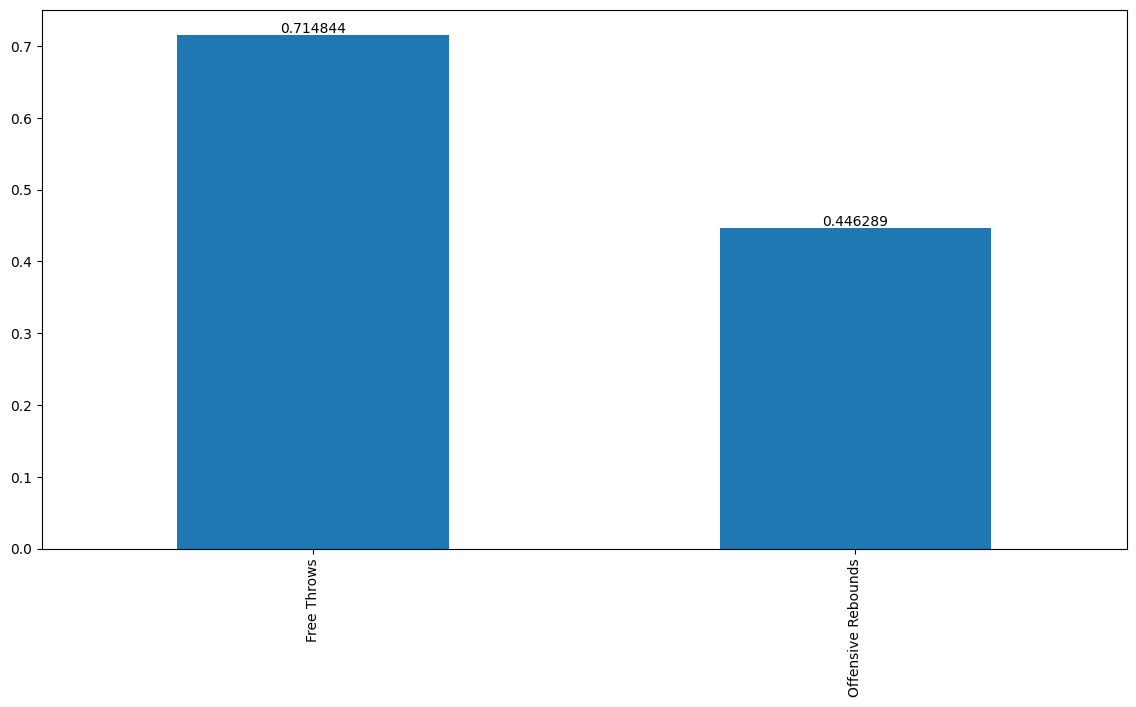

In [43]:
ax = pd.Series({
    'Free Throws' : (high_TO_games['WFTM'] > high_TO_games['LFTM']).mean(),
'Offensive Rebounds' : (high_TO_games['WOR'] > high_TO_games['LOR']).mean()
}).plot.bar(figsize = (14,7))

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Winning Teams with high turnovers (rate > 18%) record more offensive rebounds (71%) than free throws (41%). This shows that the teams rely more on offensive rebounds than free throws to win.

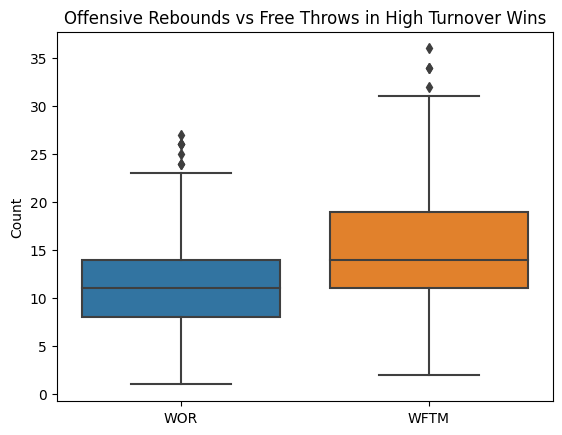

In [44]:
sb.boxplot(
    data = high_TO_games[['WOR','WFTM']]
)

plt.title("Offensive Rebounds vs Free Throws in High Turnover Wins")
plt.ylabel("Count")
plt.show()

**3. Is foul trouble more damaging in high-scoring or low-scoring games?**

In [45]:
high_scoring_games = tourney_result[tourney_result['total_score'] > 150]
low_scoring_games = tourney_result[tourney_result['total_score'] < 150]

In [46]:
high_scoring_games = high_scoring_games.copy()
low_scoring_games  = low_scoring_games.copy()

high_scoring_games['L_have_more_PF'] = high_scoring_games['LPF'] > high_scoring_games['WPF']
low_scoring_games['L_have_more_PF'] = low_scoring_games['LPF'] > low_scoring_games['WPF']

/tmp/ipykernel_13/1854567005.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13/1854567005.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13/1854567005.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13/1854567005.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent wi

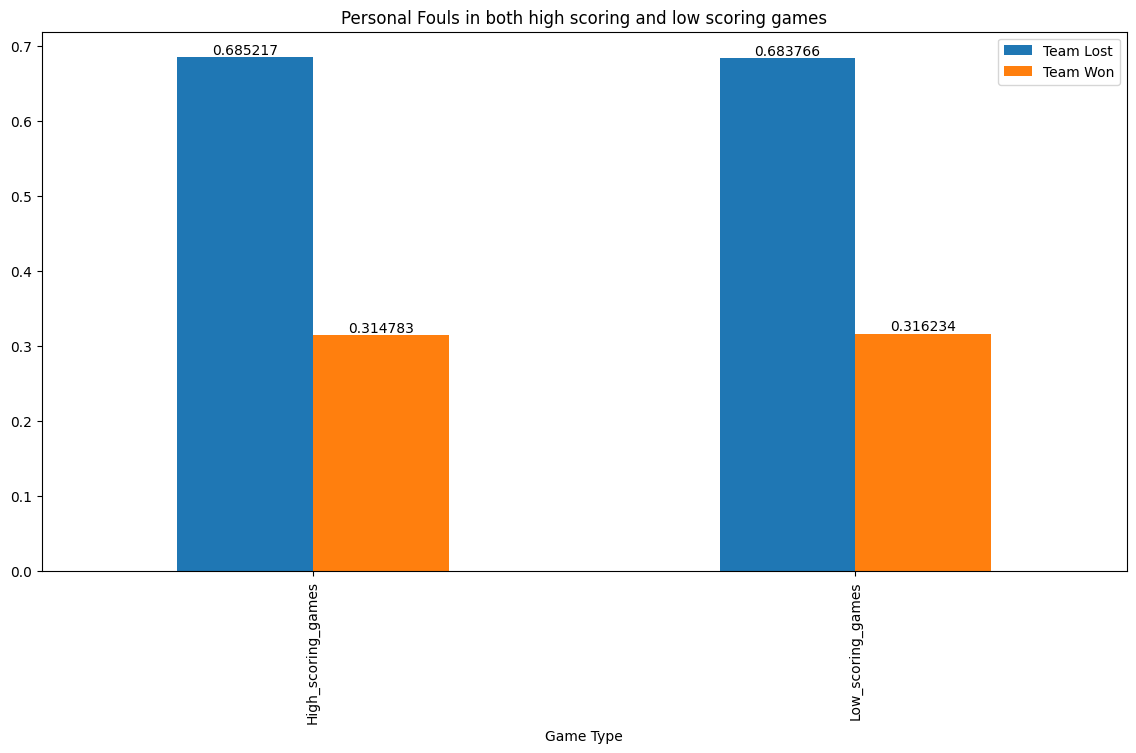

In [47]:
df = pd.DataFrame(
    [['High_scoring_games', high_scoring_games['L_have_more_PF'].value_counts(normalize = True)[0], 
              high_scoring_games['L_have_more_PF'].value_counts(normalize = True)[1]],
              ['Low_scoring_games', low_scoring_games['L_have_more_PF'].value_counts(normalize = True)[0], 
               low_scoring_games['L_have_more_PF'].value_counts(normalize = True)[1]]],
              columns = ['Game Type', 'Team Lost', 'Team Won']
            )

# plot grouped bar chart
ax = df.plot(x='Game Type',
        kind='bar',
        stacked=False,
        figsize = (14,7),
        title='Personal Fouls in both high scoring and low scoring games')

for container in ax.containers:
    ax.bar_label(container)

**Interpretation:**

- Losing teams commit more fouls 68% of the time in high-scoring games

- Losing teams commit more fouls 68% of the time in low-scoring games

**Conclusion:**

- Foul trouble appears equally as damaging in low scoring or high scoring games

#### Cleaner version

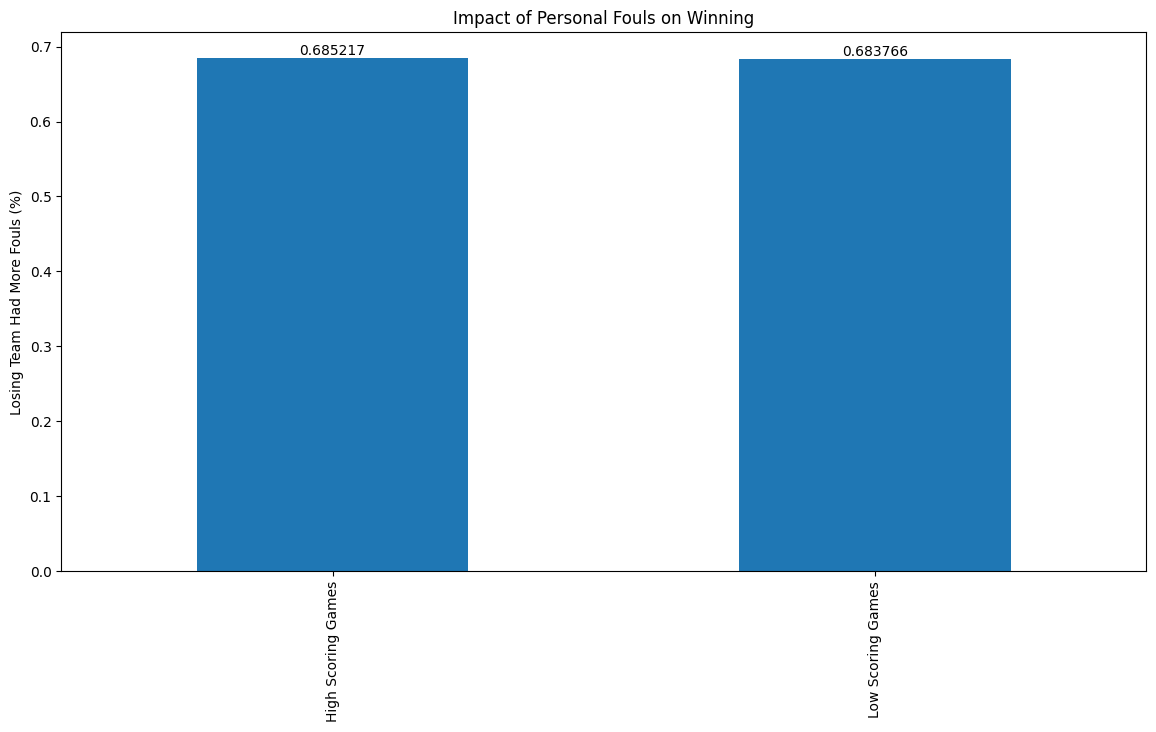

In [48]:
pf_damage = pd.Series({
    'High Scoring Games': (high_scoring_games['LPF'] > high_scoring_games['WPF']).mean(),
    'Low Scoring Games': (low_scoring_games['LPF'] > low_scoring_games['WPF']).mean()
})

ax = pf_damage.plot.bar(figsize=(14,7), title='Impact of Personal Fouls on Winning')

for container in ax.containers:
    ax.bar_label(container)

plt.ylabel('Losing Team Had More Fouls (%)')
plt.show()

**29. Which stats are the strongest predictors of winning a game?**

In [49]:
##Step 1 — Create stat differences

tourney_result['FG_diff'] = tourney_result['WFGM'] - tourney_result['LFGM']
tourney_result['OR_diff'] = tourney_result['WOR'] - tourney_result['LOR']
tourney_result['DR_diff'] = tourney_result['WDR'] - tourney_result['LDR']
tourney_result['AST_diff'] = tourney_result['WAst'] - tourney_result['LAst']
tourney_result['TO_diff'] = tourney_result['LTO'] - tourney_result['WTO']  # positive = winner had fewer turnovers
tourney_result['FT_diff'] = tourney_result['WFTM'] - tourney_result['LFTM']

tourney_result['Score_diff'] = tourney_result['WScore'] - tourney_result['LScore']

In [50]:
#Step 2 — Correlation with winning margin

stats = ['FG_diff','OR_diff','DR_diff','AST_diff','TO_diff','FT_diff']

corr = tourney_result[stats + ['Score_diff']].corr()['Score_diff'].drop('Score_diff')

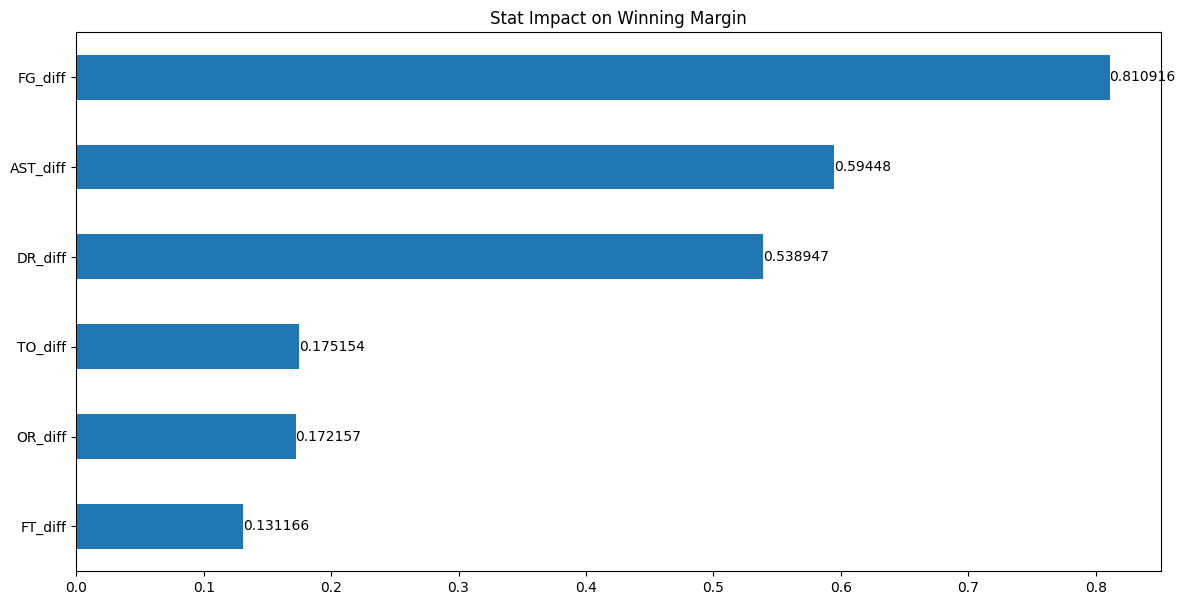

In [51]:
#Step 3 - Visualization

ax = corr.sort_values().plot.barh(figsize=(14,7), title='Stat Impact on Winning Margin')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Interpretation:**

Field goal advantage is the strongest predictor of winning margin, followed by Assists and Defensive rebounds